# metrics
> Ranking and AUCDF helpers.

In [ ]:
#| default_exp metrics

In [ ]:
#| export
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from fastcore.meta import delegates
from matplotlib import pyplot as plt

In [ ]:
df = sns.load_dataset('tips').dropna().sort_values('total_bill').reset_index(drop=True)
df.shape

(244, 7)

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,3.07,1.00,Female,Yes,Sat,Dinner,1
1,5.75,1.00,Female,Yes,Fri,Dinner,2
2,7.25,1.00,Female,No,Sat,Dinner,1
3,7.25,5.15,Male,Yes,Sun,Dinner,2
4,7.51,2.00,Male,No,Thur,Lunch,2


## Ranking Plots

In [ ]:
#| export
@delegates(sns.scatterplot)
def plot_rank(
    sorted_df: pd.DataFrame,  # dataframe already sorted by the ranking value
    x: str,  # label column used for annotations
    y: str,  # numeric ranking column
    n_hi: int | None = 10,  # number of items to annotate at the head
    n_lo: int | None = 10,  # number of items to annotate at the tail
    figsize: tuple[float, float] = (10, 8),  # figure size in inches
    **kwargs,  # forwarded scatterplot kwargs
):
    "Plot a ranked scatter and annotate the highest and lowest entries." 
    fig, ax = plt.subplots(figsize=figsize)
    sorted_df = sorted_df.reset_index(drop=True)
    sns.scatterplot(data=sorted_df, x=x, y=y, ax=ax, **kwargs)
    ax.set_xticks([])

    texts = []
    if n_hi is not None:
        for i, row in sorted_df.head(n_hi).iterrows():
            texts.append(ax.text(i, row[y], row[x], ha='center', va='bottom'))
    if n_lo is not None:
        for i, row in sorted_df.tail(n_lo).iterrows():
            texts.append(ax.text(i, row[y], row[x], ha='center', va='bottom'))
    if texts and adjust_text is not None:
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black'))
    ax.set_ylabel(y)
    plt.tight_layout()
    return ax

<Axes: xlabel='day', ylabel='total_bill'>

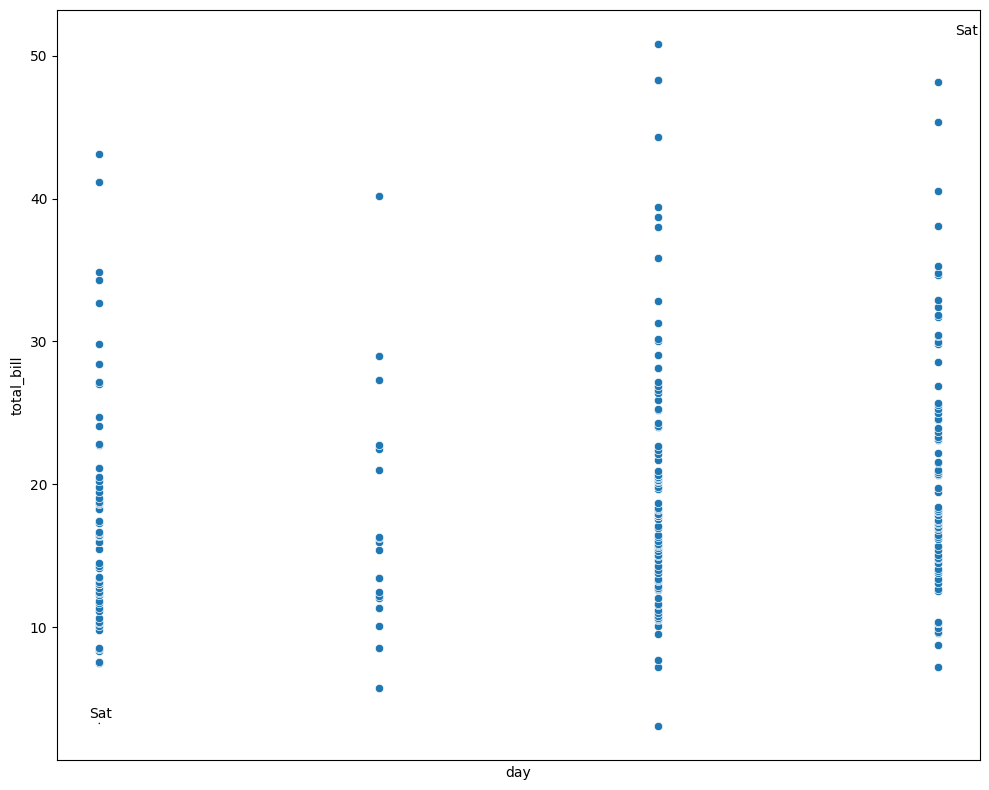

In [ ]:
plot_rank(df, x='day', y='total_bill', n_hi=1, n_lo=1)

## Rank Summary Metrics

In [ ]:
#| export
def get_AUCDF(
    df: pd.DataFrame,  # dataframe containing the ranking column
    col: str,  # numeric ranking column
    reverse: bool = False,  # flip the empirical CDF direction
    plot: bool = True,  # whether to draw the histogram and CDF panels
    xlabel: str = 'Rank of reported kinase',  # x-axis label for the histogram
) -> float:
    "Compute the normalized area under an empirical CDF over rank values."
    x_values = df[col].dropna().sort_values().to_numpy()
    if len(x_values) == 0:
        raise ValueError(f'column {col!r} does not contain any numeric values after dropping NA')
    if len(x_values) < 2 or x_values[0] == x_values[-1]:
        raise ValueError('get_AUCDF requires at least two distinct x values for normalization')

    y_values = pd.Series(x_values).rank(method='average', pct=True).values
    if reverse:
        y_values = 1 - y_values + y_values.min()

    area_under_curve = np.trapezoid(y_values, x_values)
    total_area = x_values[-1] - x_values[0]
    aucdf = area_under_curve / total_area
    if reverse:
        aucdf = -aucdf

    if plot:
        fig, ax1 = plt.subplots(figsize=(7, 5))
        fontsize = 17
        sns.histplot(x_values, bins=20, ax=ax1)
        ax1.set_xlabel(xlabel, fontsize=fontsize)
        ax1.set_ylabel('Substrates', color='darkblue', fontsize=fontsize)
        ax1.tick_params(axis='y', labelcolor='darkblue', labelsize=fontsize)
        ax1.tick_params(axis='x', labelcolor='black', labelsize=fontsize)
        ax1.set_xlim(min(x_values), max(x_values))

        ax2 = ax1.twinx()
        ax2.plot(x_values, y_values, color='darkred', linestyle='-', linewidth=2.0)
        if reverse:
            ax2.plot([max(x_values), 0], [0, max(y_values)], 'k--')
        else:
            ax2.plot([0, max(x_values)], [0, max(y_values)], 'k--')
        ax2.set_ylabel('Probability', color='darkred', fontsize=fontsize, rotation=270, labelpad=18)
        text_x = 0.45 if reverse else 0.95
        ax2.text(text_x, 0.3, f'AUCDF:{round(aucdf, 4)}', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=fontsize)
        ax2.tick_params(axis='y', labelcolor='darkred', labelsize=fontsize)
        ax2.set_ylim(0, 1)
        plt.title(f'{len(x_values):,} kinase-substrate pairs', fontsize=fontsize)
        plt.show()

    return float(aucdf)

In [ ]:
get_AUCDF(df, 'total_bill', plot=False)

0.6519265042202643

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()